# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames

#Ruta de la plataforma
# orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
# products       = pd.read_csv('/datasets/products.csv', sep=';')
# departments    = pd.read_csv('/datasets/departments.csv', sep=';')
# aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')
# order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

In [3]:
# Lee el archivo y almacénalo en df
#IMPORTANTE: este bloque no es estrictamente necesario, pero es util al correr en local

try:
    #Ruta de la plataforma
    orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
    products       = pd.read_csv('/datasets/products.csv', sep=';')
    departments    = pd.read_csv('/datasets/departments.csv', sep=';')
    aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')
    order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
except:
    # ruta local (archivo en repositorio)
    orders         = pd.read_csv('instacart_orders.csv', sep=';')
    products       = pd.read_csv('products.csv', sep=';')
    departments    = pd.read_csv('departments.csv', sep=';')
    aisles         = pd.read_csv('aisles.csv', sep=';')
    order_products = pd.read_csv('order_products.csv', sep=';')
    
    # ruta para acceder a datos en linea
    # orders         = pd.read_csv('https://code.s3.yandex.net/datasets/instacart_orders.csv', sep=';')
    # products       = pd.read_csv('https://code.s3.yandex.net/datasets/products.csv', sep=';')
    # departments    = pd.read_csv('https://code.s3.yandex.net/datasets/departments.csv', sep=';')
    # # aisles         = pd.read_csv('https://code.s3.yandex.net/datasets/aisles.csv', sep=';')
    # # order_products = pd.read_csv('https://code.s3.yandex.net/datasets/order_products.csv', sep=';')

In [4]:
# mostrar información del DataFrame
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [5]:
# mostrar información del DataFrame
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [6]:
# mostrar información del DataFrame
departments.info()
departments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [7]:
# mostrar información del DataFrame
aisles.info()
aisles.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [8]:
# mostrar información del DataFrame
order_products.info(show_counts=True)
order_products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [9]:
# Revisa si hay pedidos duplicados
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [10]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

#SOLUCION: Filtrado con indexación booleana
orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]

#SOLUCION: Filtrado con el método query()
orders.query("order_dow == 3 & order_hour_of_day == 2")

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


¿Qué sugiere este resultado?

In [11]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates().reset_index(drop=True)

In [12]:
# Vuelve a verificar si hay filas duplicadas
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [13]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
orders[orders.duplicated(subset="order_id")]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Describe brevemente tus hallazgos y lo que hiciste con ellos

### `products` data frame

In [14]:
# Verifica si hay filas totalmente duplicadas
products[products.duplicated()]

,product_id,product_name,aisle_id,department_id


In [15]:
# Revisa únicamente si hay ID de productos duplicados
products[products.duplicated(subset='product_id')]

,product_id,product_name,aisle_id,department_id


In [16]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
#products['product_name'] = products['product_name'].str.upper()
#products[products['product_name'].duplicated()]

products[products['product_name'].str.upper().duplicated()]

,product_id,product_name,aisle_id,department_id
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
436,437,NaN,100,21
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


In [17]:
# Revisa si hay nombres duplicados de productos no faltantes
products[ ~(products['product_name'].isna()) & (products['product_name'].str.lower().duplicated()) ]

,product_id,product_name,aisle_id,department_id
2058,2059,Biotin 1000 Mcg,47,11
5455,5456,Green Tea With Ginseng and Honey,96,20
5558,5559,Cream Of Mushroom Soup,69,15
7558,7559,Cinnamon Rolls with Icing,105,13
9037,9038,American Cheese slices,21,16
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `departments` data frame

In [18]:
# Revisa si hay filas totalmente duplicadas
departments[departments.duplicated()]

,department_id,department


In [19]:
# Revisa únicamente si hay IDs duplicadas de departamentos
departments[departments.duplicated(subset='department_id')]

,department_id,department


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `aisles` data frame

In [20]:
# Revisa si hay filas totalmente duplicadas
aisles[aisles.duplicated()]

,aisle_id,aisle


In [21]:
# Revisa únicamente si hay IDs duplicadas de pasillos
aisles[aisles.duplicated(subset='aisle_id')]

,aisle_id,aisle


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [22]:
# Revisa si hay filas totalmente duplicadas
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


In [23]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
order_products[order_products.duplicated(subset=['order_id', 'product_id'])]

,order_id,product_id,add_to_cart_order,reordered


Describe brevemente tus hallazgos y lo que hiciste con ellos.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [24]:
# Encuentra los valores ausentes en la columna 'product_name'
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

In [25]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
products[(products['product_name'].isna()) & (products['aisle_id'] == 100)]

#products[(products['product_name'].isna()) & (products['aisle_id'] != 100)]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

In [26]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
products[(products['product_name'].isna()) & (products['department_id'] == 21)]

#products[(products['product_name'].isna()) & (products['department_id'] != 21)]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos.

In [27]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(departments[departments['department_id'] == 21])
print()
print(aisles[aisles['aisle_id'] == 100])

    department_id department
20             21    missing

    aisle_id    aisle
99       100  missing


Describe brevemente cuáles son tus hallazgos.

In [28]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   49694 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `orders` data frame

In [29]:
# Encuentra los valores ausentes
orders[orders['days_since_prior_order'].isna()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478880,2589657,205028,1,0,16,NaN
478881,2222353,141211,1,2,13,NaN
478907,2272807,204154,1,1,15,NaN
478911,2499542,68810,1,4,19,NaN


In [30]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
orders[(orders['days_since_prior_order'].isna()) & (orders['order_number'] != 1)]

#orders[(orders['days_since_prior_order'].isna()) & (orders['order_number'] == 1)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [31]:
# Encuentra los valores ausentes
order_products[order_products['add_to_cart_order'].isna()]

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1
...,...,...,...,...
4505662,1800005,7411,NaN,0
4511400,1633337,260,NaN,0
4517562,404157,9517,NaN,0
4534112,1673227,17835,NaN,0


In [32]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(order_products['add_to_cart_order'].min())
print(order_products['add_to_cart_order'].max())

1.0
64.0


Describe brevemente cuáles son tus hallazgos.

In [33]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

# SOLUCION 1: Filtrado con indexación booleana + .tolist() + .sort()
miss_cart_order_ids = order_products[order_products["add_to_cart_order"].isna()] ["order_id"] .unique() .tolist()
miss_cart_order_ids.sort()

# SOLUCION 2: Filtrado con indexación booleana + list() + sorted()
#miss_cart_order_ids = sorted( list( order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique() ) )

# SOLUCION 3: Filtrado con el método query()
miss_cart_order_ids = ( order_products.query("add_to_cart_order.isna()")["order_id"].unique().tolist() ) 
miss_cart_order_ids.sort()

miss_cart_order_ids

[9310,
 61355,
 102236,
 129627,
 165801,
 171934,
 180546,
 264710,
 293169,
 388234,
 404157,
 678116,
 733526,
 747668,
 813364,
 844733,
 854647,
 871281,
 888470,
 903110,
 936852,
 1021563,
 1038146,
 1169835,
 1183255,
 1220886,
 1302315,
 1308785,
 1386261,
 1477139,
 1529171,
 1564093,
 1598369,
 1625713,
 1633337,
 1648217,
 1673227,
 1677118,
 1713430,
 1717990,
 1730767,
 1800005,
 1832957,
 1888628,
 1916118,
 1959075,
 1961723,
 1968313,
 2094761,
 2136777,
 2170451,
 2256933,
 2409109,
 2449164,
 2470674,
 2479011,
 2621907,
 2625444,
 2652650,
 2721963,
 2729254,
 2849370,
 2926893,
 2979697,
 2997021,
 2999801,
 3125735,
 3308010,
 3347453,
 3383594]

In [34]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

#SOLUCION: Filtrado con indexación + .groupby() + columna.count()
order_products[order_products['order_id'].isin(miss_cart_order_ids)] .groupby('order_id')["product_id"].count().sort_values()

#SOLUCION: Filtrado con el método query() + .groupby() + .size()
order_products.query("order_id in @miss_cart_order_ids") .groupby("order_id").size().sort_values()

#SOLUCION: Filtrado con .loc + value_counts() que cuenta y ordena
order_products.loc[order_products["order_id"].isin(miss_cart_order_ids), "order_id"].value_counts(ascending=True)


order_id
2170451     65
888470      65
2652650     65
1598369     65
2729254     65
          ... 
1959075     98
171934     104
2136777    108
3308010    115
61355      127
Name: count, Length: 70, dtype: int64

Describe brevemente cuáles son tus hallazgos.

In [35]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
#order_products['add_to_cart_order'].fillna(999, inplace=True)
#order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype('int')
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int32
 3   reordered          4545007 non-null  int64
dtypes: int32(1), int64(3)
memory usage: 121.4 MB


Describe brevemente tus hallazgos y lo que hiciste con ellos.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [36]:
# Observar valores de columna order_hour_of_day
# SOLUCION: usar sorted()
print(sorted(orders['order_hour_of_day'].unique()))
print()

# SOLUCION: guardar y usar .sort() por separado
hours = orders['order_hour_of_day'].unique()
hours.sort()
print(hours)
print()

# SOLUCION: usar np.sort()
import numpy as np
print(np.sort(orders['order_hour_of_day'].unique()))

# SOLUCION: convertir a Series y usar .sort_values()
pd.Series(orders['order_hour_of_day'].unique()).sort_values()#.values

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


12     0
15     1
18     2
20     3
23     4
22     5
17     6
16     7
5      8
9      9
11    10
4     11
1     12
0     13
13    14
7     15
8     16
14    17
6     18
2     19
3     20
19    21
10    22
21    23
dtype: int64

In [37]:
# SOLUCION: usar sorted()
sorted(orders['order_dow'].unique())

[0, 1, 2, 3, 4, 5, 6]

Escribe aquí tus conclusiones

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [38]:
#SOLUCION: value_counts()
orders_per_hour = orders['order_hour_of_day'].value_counts().sort_index()

#SOLUCION: groupby()
orders_per_hour = orders.groupby("order_hour_of_day")["order_id"].count()

#SOLUCION: pivot_table
orders_per_hour = orders.pivot_table(index='order_hour_of_day', values='user_id', aggfunc='nunique')

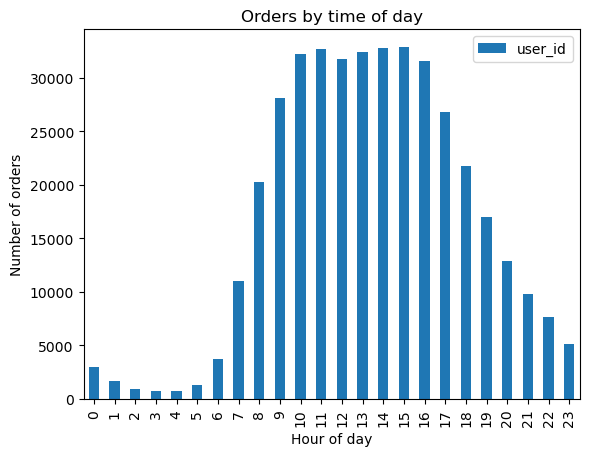

In [39]:
orders_per_hour.plot(kind='bar',
                        title='Orders by time of day',
                        xlabel='Hour of day',
                        ylabel='Number of orders'
                       )
plt.show()

Escribe aquí tus conclusiones

### [A3] ¿Qué día de la semana compran víveres las personas?

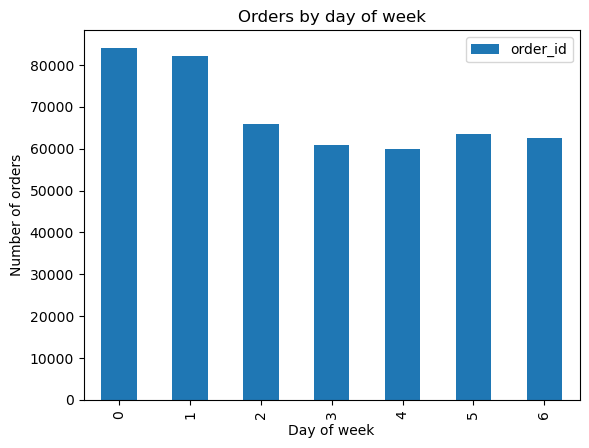

In [40]:
#SOLUCION: value_counts()
orders_per_day = orders['order_dow'].value_counts().sort_index()

#SOLUCION: groupby()
orders_per_day = orders.groupby("order_dow")["order_id"].count()

#SOLUCION: pivot_table
orders_per_day = orders.pivot_table(index='order_dow', values='order_id', aggfunc='nunique')

orders_per_day.plot(kind='bar',
                        title='Orders by day of week',
                        xlabel='Day of week',
                        ylabel='Number of orders'
                       )
plt.show()

Escribe aquí tus conclusiones

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

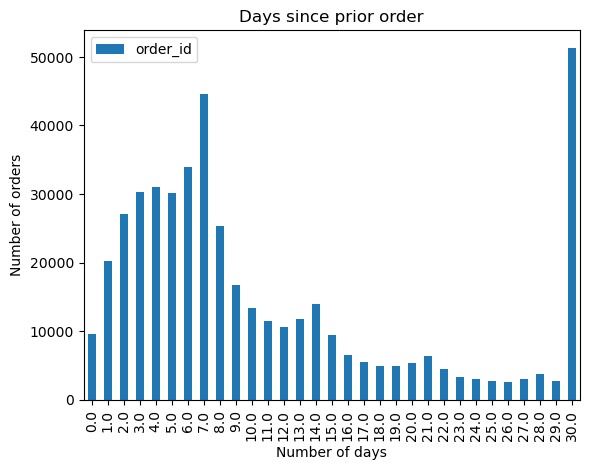

In [41]:
#SOLUCION: value_counts()
#days_since_order = orders['days_since_prior_order'].value_counts().sort_index()

#SOLUCION: groupby()
days_since_order = orders.groupby("days_since_prior_order")["order_id"].count()

#SOLUCION: pivot_table
days_since_order = orders.pivot_table(index='days_since_prior_order', values='order_id', aggfunc='nunique')

days_since_order.plot(kind='bar',
                      title='Days since prior order',
                      xlabel='Number of days',
                      ylabel='Number of orders' )
plt.show()

Escribe aquí tus conclusiones

El valor de 0 probablemente sea de clientes que hicieron mas de una orden el mismo día.

El valor de 30 días tiene un comportamiento muy diferente al resto de la gráfica, probablemente sea un error. Podemos quitarlo de la gráfica para observar mejor la distribución de los datos.

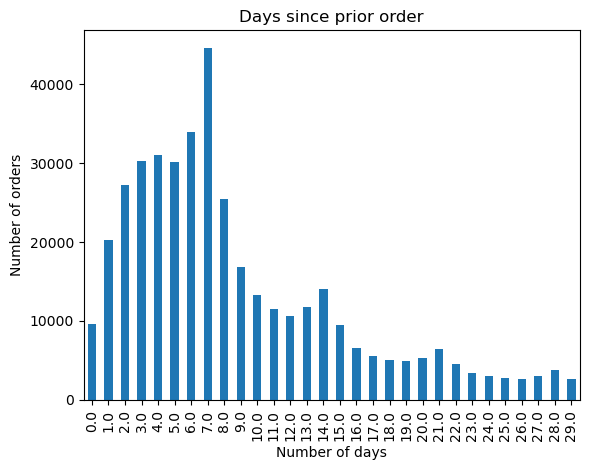

In [42]:
days_filter = orders[orders['days_since_prior_order'] < 30]
# xlim no funciona porque en gráficos de barras (kind='bar'), el eje X son categorías, no números
days_filter['days_since_prior_order'].value_counts().sort_index().plot(kind='bar',
                                                                  title='Days since prior order',
                                                                  xlabel='Number of days',
                                                                  ylabel='Number of orders',
                                                                  )
plt.show()

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [43]:
# SOLUCION 1: filtrar y concatenar
hod_counts_wed = orders[ orders['order_dow'] == 3 ]['order_hour_of_day'].value_counts().sort_index()
hod_counts_sat = orders[ orders['order_dow'] == 6 ]['order_hour_of_day'].value_counts().sort_index()

hod_counts = pd.concat([hod_counts_wed, hod_counts_sat], axis=1)
hod_counts.columns = ['Wednesday', 'Saturday']
hod_counts

,Wednesday,Saturday
order_hour_of_day,,
0,373,464
1,215,254
2,106,177
3,101,125
4,108,118
5,170,161
6,643,451
7,1732,1619
8,3125,3246


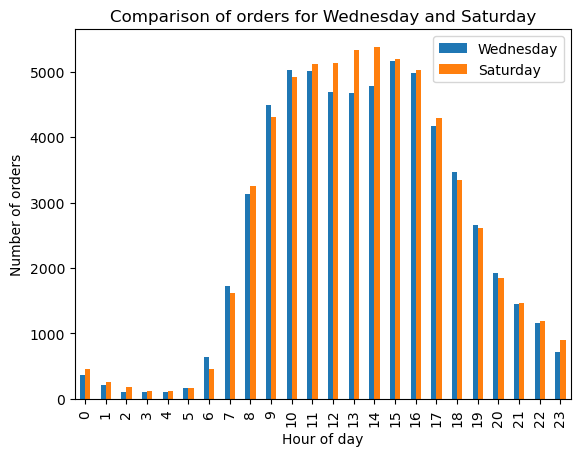

In [44]:
# SOLUCION 1: graficar
hod_counts.plot(kind='bar',
                title='Comparison of orders for Wednesday and Saturday',
                xlabel='Hour of day',
                ylabel='Number of orders'
               )
plt.show()

<Axes: title={'center': 'Orders on Wednesday and Saturday'}, xlabel='Day of the Week', ylabel='# of Orders'>

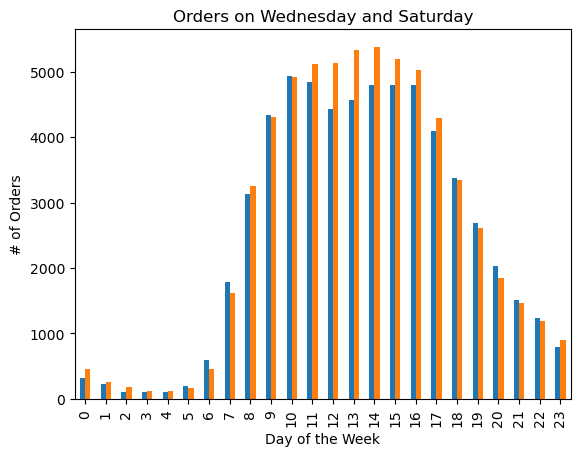

In [45]:
# SOLUCION 2: agrupar y usar unstack 
df_order_count_per_day_per_hour = orders.groupby(["order_hour_of_day", "order_dow"])["order_id"].count().unstack()

# filtrar los dias
#df_order_count_wednesday_saturday=df_order_count_per_day_per_hour[df_order_count_per_day_per_hour["order_dow"].isin([4, 6])]
df_order_count_wednesday_saturday = df_order_count_per_day_per_hour[[4, 6]]

# graficar
df_order_count_wednesday_saturday.plot(kind="bar", title="Orders on Wednesday and Saturday", xlabel="Day of the Week", ylabel="# of Orders", legend=False)


Escribe aquí tus conclusiones

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

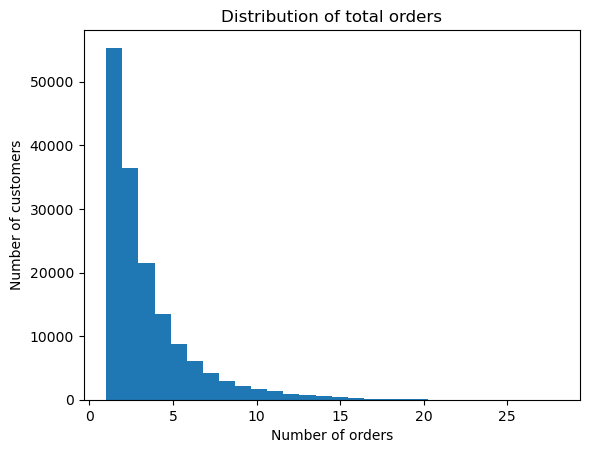

In [46]:
# Solución 1: groupby() + histograma
order_count_per_user = orders.groupby('user_id')['order_id'].count().sort_values()

order_count_per_user.plot(kind='hist',
                          bins=28,
                          title='Distribution of total orders'
                         )
plt.xlabel('Number of orders')
plt.ylabel('Number of customers')
plt.show()

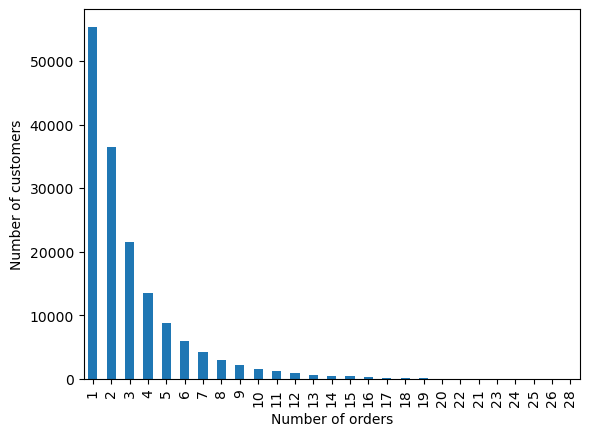

In [47]:
# Solución 2: value_counts() + barras
order_count_per_user.value_counts().plot(kind="bar")
plt.xlabel('Number of orders')
plt.ylabel('Number of customers')
plt.show()

Escribe aquí tus conclusiones

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [48]:
# combinar DFs
df_merge = order_products.merge(products, on='product_id')
df_merge

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,2141543,11440,17,0,Chicken Breast Tenders Breaded,129,1
1,567889,1560,1,1,Bag Of Ice,37,1
2,2261212,26683,1,1,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91,16
3,491251,8670,35,1,Diced Tomatoes,81,15
4,2571142,1940,5,1,Organic 2% Reduced Fat Milk,84,16
...,...,...,...,...,...,...,...
4545002,577211,15290,12,1,Orange Bell Pepper,83,4
4545003,1219554,21914,9,0,Peanut Butter & Jelly Fruit & Nut Food Bar,3,19
4545004,692640,47766,4,1,Organic Avocado,24,4
4545005,319435,691,8,1,Organic Promise Strawberry Fields Cereal,121,14


In [49]:
# SOLUCION: groupby() + col count()
top_products = df_merge.groupby(['product_id', 'product_name'])["order_id"].count().sort_values(ascending=False)
# SOLUCION: groupby() + size()
top_products = df_merge.groupby(['product_id', 'product_name']).size().sort_values(ascending=False)

top_products.head(20)

product_id  product_name            
24852       Banana                      66050
13176       Bag of Organic Bananas      53297
21137       Organic Strawberries        37039
21903       Organic Baby Spinach        33971
47209       Organic Hass Avocado        29773
47766       Organic Avocado             24689
47626       Large Lemon                 21495
16797       Strawberries                20018
26209       Limes                       19690
27845       Organic Whole Milk          19600
27966       Organic Raspberries         19197
22935       Organic Yellow Onion        15898
24964       Organic Garlic              15292
45007       Organic Zucchini            14584
39275       Organic Blueberries         13879
49683       Cucumber Kirby              13675
28204       Organic Fuji Apple          12544
5876        Organic Lemon               12232
8277        Apple Honeycrisp Organic    11993
40706       Organic Grape Tomatoes      11781
dtype: int64

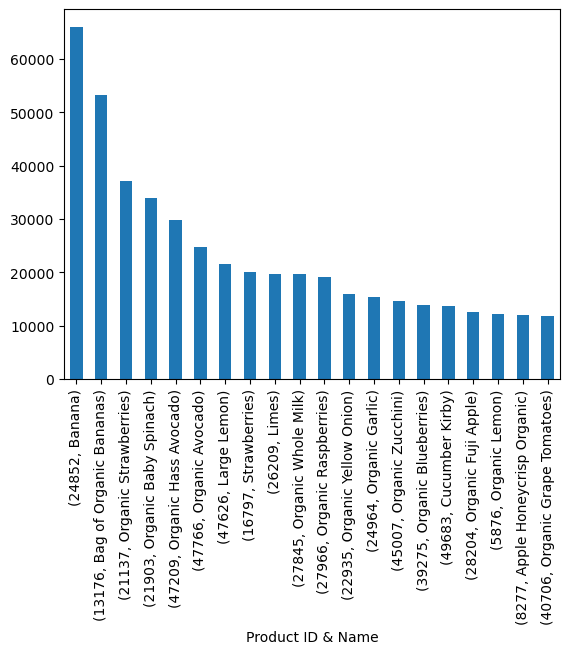

In [50]:
top_products.head(20).plot.bar()
plt.xlabel('Product ID & Name')
plt.show()

Escribe aquí tus conclusiones

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [51]:
num_items = order_products.groupby('order_id').count()['product_id']
histogram_vals = num_items.value_counts().sort_index()
histogram_vals

#order_products.groupby('order_id')['product_id'].count().value_counts().sort_index().plot(kind="bar")

product_id
1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: count, Length: 90, dtype: int64

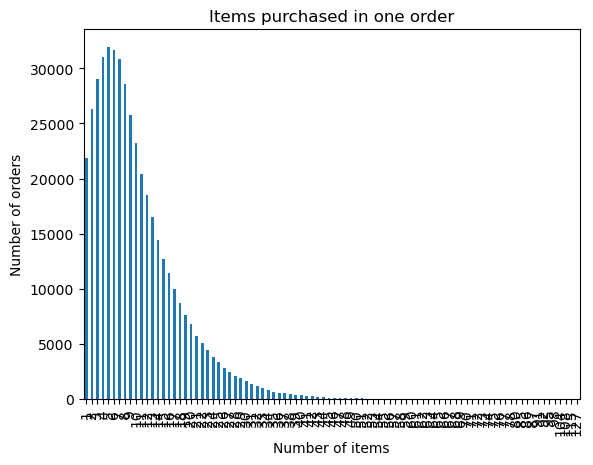

In [52]:
histogram_vals.plot(kind='bar',
                title='Items purchased in one order',
                xlabel='Number of items',
                ylabel='Number of orders'
               )
plt.show()

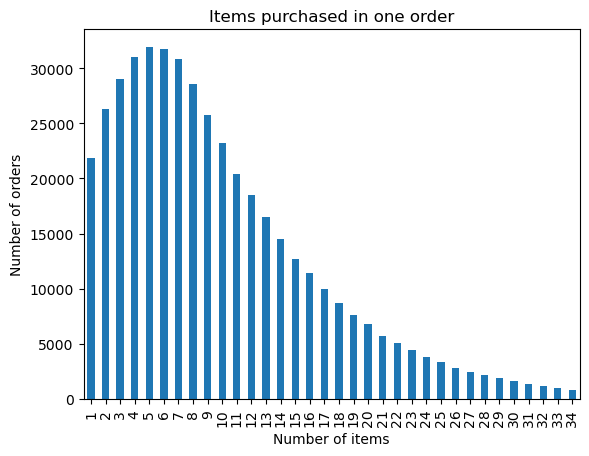

In [53]:
histogram_vals[histogram_vals.index < 35].plot(kind='bar',
                title='Items purchased in one order',
                xlabel='Number of items',
                ylabel='Number of orders'
               )
plt.show()

Escribe aquí tus conclusiones

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [54]:
reorder_products = order_products[order_products['reordered'] == 1]
merge_reordered = reorder_products.merge(products, on='product_id')
merge_reordered

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,567889,1560,1,1,Bag Of Ice,37,1
1,2261212,26683,1,1,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91,16
2,491251,8670,35,1,Diced Tomatoes,81,15
3,2571142,1940,5,1,Organic 2% Reduced Fat Milk,84,16
4,2456893,21616,4,1,Organic Baby Arugula,123,4
...,...,...,...,...,...,...,...
2683833,1622300,24852,1,1,Banana,24,4
2683834,1125324,40600,6,1,Cheese Stuffed Crust Pepperoni Pizza,79,1
2683835,577211,15290,12,1,Orange Bell Pepper,83,4
2683836,692640,47766,4,1,Organic Avocado,24,4


In [55]:
top_reordered_products = merge_reordered.groupby(['product_id', 'product_name']).size().sort_values(ascending=False)
top_reordered_products.head(20)

product_id  product_name            
24852       Banana                      55763
13176       Bag of Organic Bananas      44450
21137       Organic Strawberries        28639
21903       Organic Baby Spinach        26233
47209       Organic Hass Avocado        23629
47766       Organic Avocado             18743
27845       Organic Whole Milk          16251
47626       Large Lemon                 15044
27966       Organic Raspberries         14748
16797       Strawberries                13945
26209       Limes                       13327
22935       Organic Yellow Onion        11145
24964       Organic Garlic              10411
45007       Organic Zucchini            10076
49683       Cucumber Kirby               9538
28204       Organic Fuji Apple           8989
8277        Apple Honeycrisp Organic     8836
39275       Organic Blueberries          8799
5876        Organic Lemon                8412
49235       Organic Half & Half          8389
dtype: int64

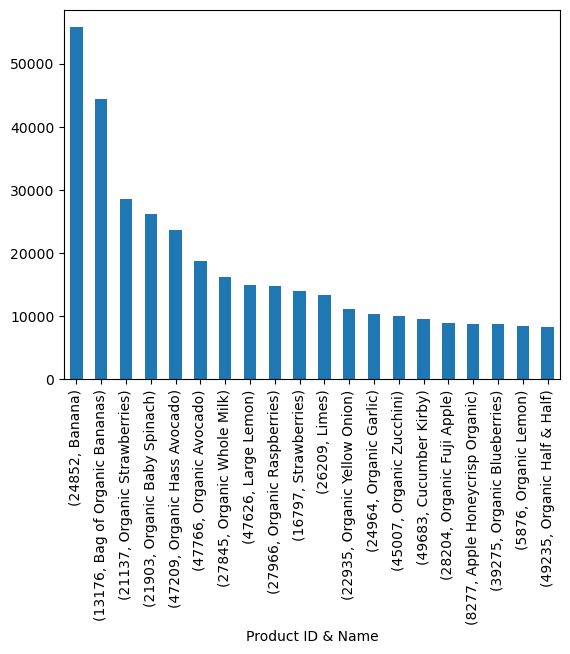

In [56]:
top_reordered_products.head(20).plot.bar()
plt.xlabel('Product ID & Name')
plt.show()

Escribe aquí tus conclusiones

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [57]:
# Verificar valores de columna reordered
order_products['reordered'].unique()

array([0, 1], dtype=int64)

In [58]:
merge_orderP_products = order_products.merge(products)

# SOLUCIÓN basica: sumar, después dividir entre el total
reorder_grouped = merge_orderP_products.groupby(['product_id', 'product_name'])['reordered']
reorder_rate = reorder_grouped.sum()/reorder_grouped.count()

#SOLUCIÓN rapida: sumar y dividir aplicando promedio
reorder_rate = merge_orderP_products.groupby(['product_id', 'product_name'])['reordered'].mean()
reorder_rate

product_id  product_name                                                     
1           Chocolate Sandwich Cookies                                           0.564286
2           All-Seasons Salt                                                     0.000000
3           Robust Golden Unsweetened Oolong Tea                                 0.738095
4           Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce    0.510204
7           Pure Coconut Water With Orange                                       0.500000
                                                                                   ...   
49690       HIGH PERFORMANCE ENERGY DRINK                                        0.800000
49691       ORIGINAL PANCAKE & WAFFLE MIX                                        0.430556
49692       ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR                      0.416667
49693       SPRING WATER BODY WASH                                               0.440000
49694       BURRITO- S

In [59]:
reorder_rate_as_df = reorder_rate.sort_values(ascending=False).reset_index()
reorder_rate_as_df.sort_values(by='product_id')

,product_id,product_name,reordered
12126,1,Chocolate Sandwich Cookies,0.564286
43403,2,All-Seasons Salt,0.000000
3834,3,Robust Golden Unsweetened Oolong Tea,0.738095
14955,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,0.510204
18024,7,Pure Coconut Water With Orange,0.500000
...,...,...,...
2623,49690,HIGH PERFORMANCE ENERGY DRINK,0.800000
21509,49691,ORIGINAL PANCAKE & WAFFLE MIX,0.430556
22342,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,0.416667
21155,49693,SPRING WATER BODY WASH,0.440000


Escribe aquí tus conclusiones

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [60]:
merge_orderP_orders = order_products.merge(orders)

# SOLUCIÓN basica: sumar, después dividir entre el total
reorder_pct_grouped = merge_orderP_orders.groupby('user_id')['reordered']
reorder_pct_rate = reorder_pct_grouped.sum()/reorder_pct_grouped.count()

#SOLUCIÓN avanzada/rapida: sumar y dividir aplicando promedio
reorder_pct = merge_orderP_orders.groupby('user_id')['reordered'].mean()

reorder_pct_rate

user_id
2         0.038462
4         0.000000
5         0.666667
6         0.000000
7         0.928571
            ...   
206203    0.222222
206206    0.714286
206207    0.891304
206208    0.696000
206209    0.320000
Name: reordered, Length: 149626, dtype: float64

In [61]:
reorder_pct_as_df = reorder_pct.sort_values(ascending=False).reset_index()
reorder_pct_as_df

,user_id,reordered
0,137587,1.0
1,173474,1.0
2,13918,1.0
3,62300,1.0
4,62307,1.0
...,...,...
149621,190953,0.0
149622,119371,0.0
149623,63173,0.0
149624,63163,0.0


In [62]:
# EXTRA: Observar mejor todo el comportamiento
reorder_pct_as_df["reordered"].describe()

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: reordered, dtype: float64

Escribe aquí tus conclusiones

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [63]:
merge_orderP_products.head(3)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,2141543,11440,17,0,Chicken Breast Tenders Breaded,129,1
1,567889,1560,1,1,Bag Of Ice,37,1
2,2261212,26683,1,1,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91,16


In [64]:
#filtrar primeros productos añadidos al carrito
first_in_cart = merge_orderP_products[merge_orderP_products['add_to_cart_order'] == 1]
first_in_cart.head(3)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
1,567889,1560,1,1,Bag Of Ice,37,1
2,2261212,26683,1,1,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91,16
14,1961225,37553,1,1,Iced Coffee Lightly Sweet,26,7


In [65]:
first_count = first_in_cart.groupby(['product_id', 'product_name'])['product_id'].count().sort_values(ascending=False)
first_count.head(20)

product_id  product_name               
24852       Banana                         15562
13176       Bag of Organic Bananas         11026
27845       Organic Whole Milk              4363
21137       Organic Strawberries            3946
47209       Organic Hass Avocado            3390
21903       Organic Baby Spinach            3336
47766       Organic Avocado                 3044
19660       Spring Water                    2336
16797       Strawberries                    2308
27966       Organic Raspberries             2024
44632       Sparkling Water Grapefruit      1914
49235       Organic Half & Half             1797
47626       Large Lemon                     1737
196         Soda                            1733
38689       Organic Reduced Fat Milk        1397
26209       Limes                           1370
12341       Hass Avocados                   1340
5785        Organic Reduced Fat 2% Milk     1310
27086       Half & Half                     1309
43352       Raspberries      

Escribe aquí tus conclusiones

### Conclusion general del proyecto: